# OCR pipeline after plate detection

## Цель
Построить baseline-пайплайн:
1. загрузка изображения;
2. детекция таблички;
3. вырезание таблички из исходного изображения;
4. OCR;
5. постобработка распознанного номера.

## Импорты

In [1]:
from pathlib import Path
import random
import re

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd

from ultralytics import YOLO

## Пути

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATASET_DIR = PROJECT_ROOT / "dataset"
IMAGES_DIR = DATASET_DIR / "images"
MODEL_PATH = PROJECT_ROOT / "runs" / "detect" / "train4" / "weights" / "best.pt"

print("MODEL_PATH exists:", MODEL_PATH.exists())
print("TRAIN DIR exists:", (IMAGES_DIR / "train").exists())
print("VAL DIR exists:", (IMAGES_DIR / "val").exists())

MODEL_PATH exists: True
TRAIN DIR exists: True
VAL DIR exists: True


## Загрузка модели


In [3]:
model = YOLO(str(MODEL_PATH))
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

## Функции показа

In [4]:
def show_image(image, title="", figsize=(10, 8), cmap=None):
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [5]:
def draw_bbox_on_image(image_rgb, bbox, title="Detection"):
    x1, y1, x2, y2 = map(int, bbox)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(image_rgb)
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)
    ax.set_title(title)
    ax.axis("off")
    plt.show()

## Сбор списка изображений

In [6]:
image_paths = []
for split in ["train", "val"]:
    split_dir = IMAGES_DIR / split
    image_paths.extend([
        p for p in split_dir.glob("*")
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ])

print("Total images:", len(image_paths))

Total images: 123


## Выбор тестового изображения

MDZ089 _1.jpg


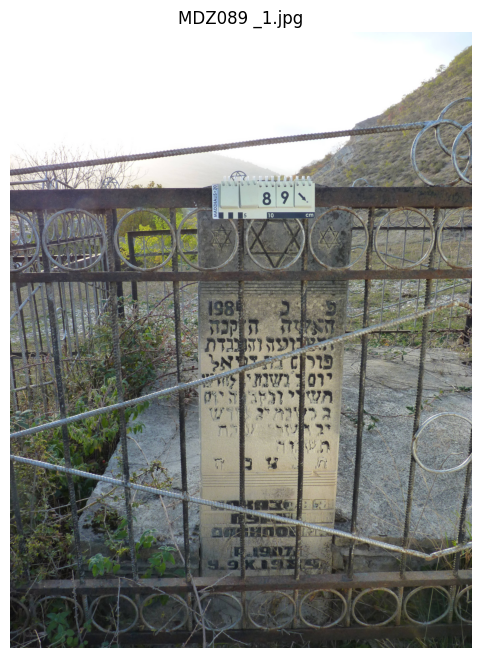

In [7]:
test_path = random.choice(image_paths)
print(test_path.name)

image_bgr = cv2.imread(str(test_path))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

show_image(image_rgb, title=test_path.name)

## Инференс модели на одном изображении

In [8]:
results = model(str(test_path), verbose=False)
result = results[0]

len(result.boxes)

1

## Лучший bbox

In [9]:
if len(result.boxes) == 0:
    print("Табличка не найдена")
else:
    boxes_xyxy = result.boxes.xyxy.cpu().numpy()
    confidences = result.boxes.conf.cpu().numpy()

    best_idx = np.argmax(confidences)

    best_bbox = boxes_xyxy[best_idx]
    best_conf = confidences[best_idx]

    print("Best confidence:", best_conf)
    print("Best bbox:", best_bbox)

Best confidence: 0.91163796
Best bbox: [     1314.1      933.08      1996.7      1214.8]


## Показ детекции

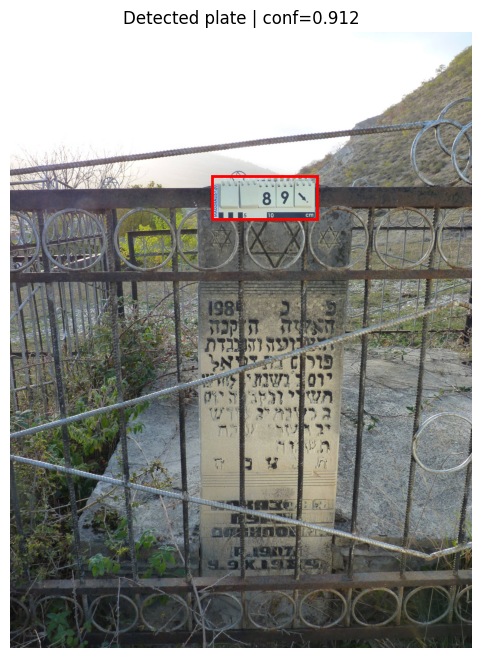

In [10]:
if len(result.boxes) > 0:
    draw_bbox_on_image(
        image_rgb,
        best_bbox,
        title=f"Detected plate | conf={best_conf:.3f}"
    )

## Вырезание таблички из исходного изображения

In [11]:
def crop_bbox(image_bgr, bbox):
    h, w = image_bgr.shape[:2]
    x1, y1, x2, y2 = map(int, bbox)

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)

    return image_bgr[y1:y2, x1:x2]

Plate shape: (281, 682, 3)


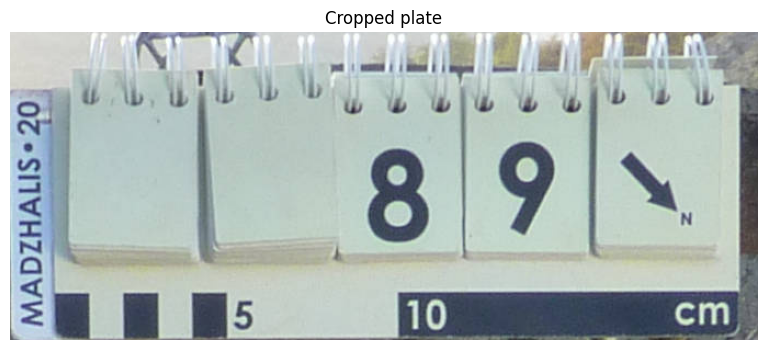

In [12]:
if len(result.boxes) > 0:
    plate_bgr = crop_bbox(image_bgr, best_bbox)
    plate_rgb = cv2.cvtColor(plate_bgr, cv2.COLOR_BGR2RGB)

    print("Plate shape:", plate_bgr.shape)
    show_image(plate_rgb, title="Cropped plate", figsize=(10, 4))

## Нормализация ориентации

Если табличка выше, чем шире - повернем

In [13]:
def normalize_plate_orientation(image_bgr):
    h, w = image_bgr.shape[:2]
    if h > w:
        image_bgr = cv2.rotate(image_bgr, cv2.ROTATE_90_CLOCKWISE)
    return image_bgr

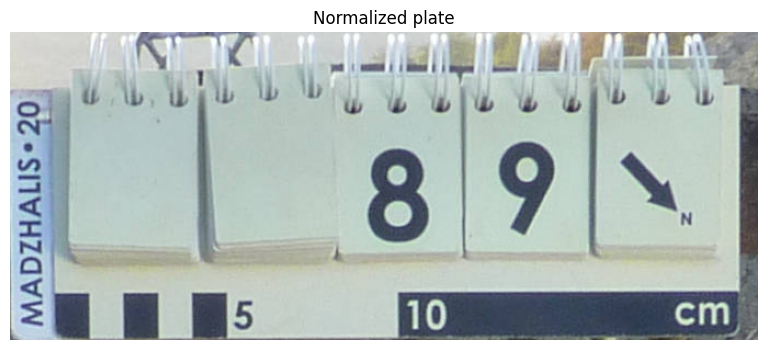

In [14]:
plate_bgr_norm = normalize_plate_orientation(plate_bgr)
plate_rgb_norm = cv2.cvtColor(plate_bgr_norm, cv2.COLOR_BGR2RGB)

show_image(plate_rgb_norm, title="Normalized plate", figsize=(10, 4))

## Подготовка под OCR

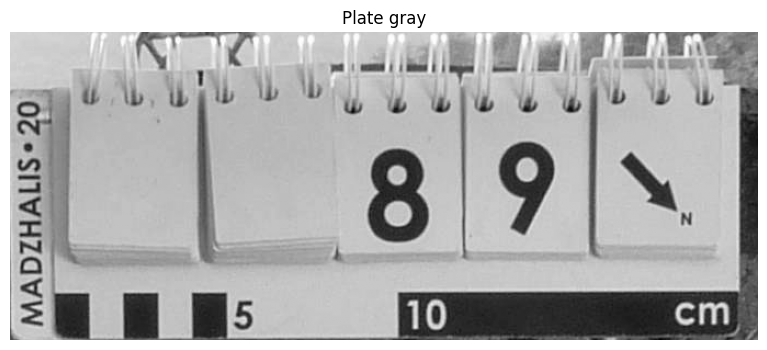

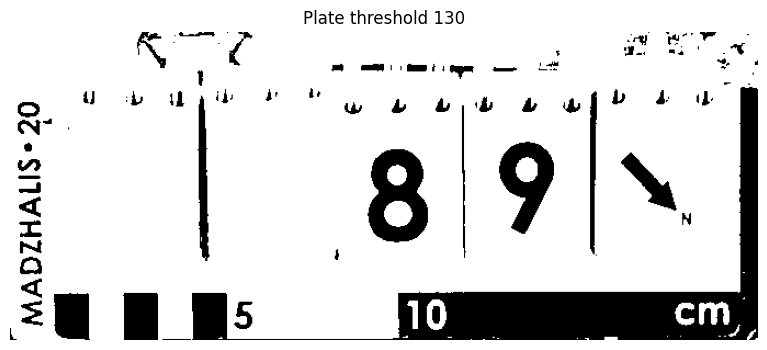

In [15]:
plate_gray = cv2.cvtColor(plate_bgr_norm, cv2.COLOR_BGR2GRAY)
_, plate_thresh = cv2.threshold(plate_gray, 130, 255, cv2.THRESH_BINARY)

show_image(plate_gray, title="Plate gray", figsize=(10, 4), cmap="gray")
show_image(plate_thresh, title="Plate threshold 130", figsize=(10, 4), cmap="gray")